## Cluster-Mass based Permutation testing in Julia

- Step 1: load and check adjacency matrix
- Step 2: generate simuated data
- Step 3: run cluster-mass permutation test

### Load Libraries

In [156]:
import Pkg
#Pkg.activate("/data/p_02865/tools/UnfoldStats.jl/docs")
Pkg.activate("..")
Pkg.instantiate()


using UnfoldSim
using MAT
using CairoMakie
using Random
using Statistics
using UnfoldMixedModels
using UnfoldStats
using DataFrames
using MixedModelsPermutations
using UnfoldMakie
using Logging
using ClusterDepth
using CSV

ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
lmm_permutations = ext.lmm_permutations
get_lmm_statistic = ext.get_lmm_statistic


include("../read_adjacency.jl")
include("../cluster_mass_test.jl")


  Activating project at `~/Desktop/ClusterComputation`


spatiotemporal_cluster_pvalues (generic function with 1 method)

In [157]:
# 1. Positions CSV
positions_df = CSV.read("channel_positions_Magda.csv", DataFrame;
                     types=[String, Float64, Float64])

# 2.adjacency CSV
adj_df = CSV.read("adjacency_Magda.csv", DataFrame; stringtype=String, strict=false)
electrode_labels = adj_df.Column1
adjacency = select!(adj_df, Not(1))
adjacency = Matrix(adjacency)
adjacency = Bool.(adjacency)

59×59 BitMatrix:
 1  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  1  1  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0     1  0  0  0  0  0  0  1  1  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  1  0  0  0  0  1
 ⋮              ⋮              ⋮        ⋱           ⋮              ⋮        
 0  0  0  0  0  0  0  0  0  0  0  0  1  …  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0 

## Correctly format the EEG data
- **60 subjects** (20 per group)
- **3 time points**
- **3 dependent variables** 1/f, alpha and beta (should all be in seperate data arrays)

In [158]:
electrode_labels

59-element Vector{String}:
 "Fp1"
 "Fp2"
 "F3"
 "F4"
 "C3"
 "C4"
 "P3"
 "P4"
 "O1"
 "O2"
 ⋮
 "TP7"
 "TP8"
 "PO7"
 "PO8"
 "Fpz"
 "AFz"
 "FCz"
 "CPz"
 "POz"

In [159]:
# read the data
#T = Float64
#T = AbstractFloat
#data_alpha = Array{T}(undef, 64, 1, 180)
data_alpha = Array{Union{Missing,Float64}}(undef, 59, 1, 180)

for (i, channel) in enumerate(electrode_labels)
    df_fooof = CSV.read("/Users/mg/Desktop/MOVE/resting_state/fooof/$(channel)_fooof_params.csv", DataFrame)
    #alpha_vector = df_fooof.beta_PW_absolute_periodic_log
    #alpha_vector = df_fooof.beta_PW_absolute_total_2
    alpha_vector = df_fooof.exponent
    #print(length(alpha_vector))
    data_alpha[i, 1, :] = alpha_vector
end

data_alpha = Float64.(coalesce.(data_alpha, NaN))  # replace "missing" with "nan" so it can be Float64
data_alpha

59×1×180 Array{Float64, 3}:
[:, :, 1] =
  0.8360041763550607
  0.8095958916985969
  0.8770377749999775
  0.9544922794493865
  1.0715342160862658
  0.7966649226582817
  0.8401945384306457
  1.224783134035843
  0.05044869715280361
  1.1435182298559021
  ⋮
  0.31705676174248265
  0.8531168108032839
 -0.022069489749499592
  1.1694057544906462
  0.864056692907466
  1.1215868544735885
  1.3791239919418796
  1.3774389987610565
  1.2806424518171557

[:, :, 2] =
  0.7611991437217451
  0.6920001311670496
  1.0220063536384636
  0.8472104743712836
  0.8925314798726309
  0.6765666602926442
  0.7954765256154538
  1.1938786327257418
  0.018357780582687333
  1.1782480708400298
  ⋮
  0.3995711117397641
  0.5615443233624156
 -0.1173890401876964
  1.0923359380418687
  0.83958406096709
  1.0781836474299755
  1.3880150575554793
  1.4254339816302624
  1.1601166564538858

[:, :, 3] =
  0.8022607863474188
  0.6930171292508188
  0.7837416649150752
  0.9520691961556303
  0.8628440444540834
  0.7974711872450576


In [160]:
# format the dependent variables for the mixed models
df_behavior = CSV.read("/Users/mg/Desktop/MOVE/MOVE_Analysis_MG/KINARM/behavioral_measure.csv", DataFrame)
rename!(df_behavior, :VP => :Subject )
df_evts = select(df_behavior, [:Subject, :Behavior, :Group])
evts = repeat(df_evts, inner = 3)
evts.Time = repeat(1:3, 60)
evts.Subject = string.(evts.Subject)  # Subject needs to be categorical for model
evts

Row,Subject,Behavior,Group,Time
,String,Float64,String1,Int64
1,1,0.0623471,C,1
2,1,0.0623471,C,2
3,1,0.0623471,C,3
4,2,-6.97687,A,1
5,2,-6.97687,A,2
6,2,-6.97687,A,3
7,3,-2.00111,M,1
8,3,-2.00111,M,2
9,3,-2.00111,M,3


In [161]:
# Fit mass-univariate LMM
# was ist mit effects coding? (bei meinem mixed model in C3, gebe ich das an!)

times = [1]

# set contrast to effectsCoding for Group to compare against mean
contr = Dict(
   :Group => EffectsCoding(base="C", levels=["A", "C", "M"]) # for ANOVA output, base does not matter in EffectsCoding
   #:Group => DummyCoding(base="M")
 )

println("Fitting LMM at each channel...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ Behavior * Group * Time + (1+Time | Subject)), # @formula(0 ~ Behavior * Group * Time + (1+Time | Subject))
            times,

        ),
    ],
    evts,
    data_alpha;
    contrasts = contr,
);

Fitting LMM at each channel...
  0.095872 seconds (69.44 k allocations: 2.211 MiB)


### 3. Perform cluster-mass permutation test

In [162]:
# --- Cluster-mass permutation test using explicit functions ---

coefficient = 6  # what effect
n_permutations = 50  # Reduced for dev; use 500-1000 for real analyses
threshold = 2.0

time_selection = 1:length(times)

# 2. Generate permutation distribution
permuted = lmm_permutations(MersenneTwister(42), m, data_alpha, coefficient;
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection
)


59×1×50 Array{Float64, 3}:
[:, :, 1] =
 -0.5288923378080501
 -0.3331577234970317
 -0.17758201511374405
 -1.2413356551357986
  0.43774923280942885
  0.09983535549548395
  0.281470217836438
  0.38844818825098937
 -0.08526373058203893
  0.04147327882125975
  ⋮
 -0.44462903393399944
 -0.7436142921203996
 -0.2692858168312466
  0.14863618174560775
 -1.0773990252495091
  0.0012803889470587404
  0.4651296705646323
  0.2361008072825142
  0.9544663655803447

[:, :, 2] =
 -0.8622847048169187
 -0.1949253140893794
 -1.5872667662459587
  0.010791641477940513
 -1.5953295736034492
 -1.7215265648178568
 -1.9310713324649786
 -1.6694381564665282
 -1.637446741141755
 -1.0957344159099667
  ⋮
 -1.3690970210395816
 -1.2862266746455582
 -2.4321175520788434
 -1.7100858402574168
 -1.3548661199532133
 -1.298087760102723
 -1.3771849837142178
 -1.4601815512177396
 -1.7133033291230635

[:, :, 3] =
 -1.4812196712161474
 -0.04962679396350031
 -0.5453032019407899
 -0.5833875737141007
  0.41815338864750207
 -0.27699928

In [163]:
coefs = coeftable(m)
unique(coefs.coefname)

12-element Vector{String}:
 "(Intercept)"
 "Behavior"
 "Group: A"
 "Group: M"
 "Time"
 "Behavior & Group: A"
 "Behavior & Group: M"
 "Behavior & Time"
 "Group: A & Time"
 "Group: M & Time"
 "Behavior & Group: A & Time"
 "Behavior & Group: M & Time"

Available columns: ["channel", "coefname", "estimate", "eventname", "group", "stderror", "time"]
Rows for stimtype: 59
Unique channels: 59
Unique times: 1

=== Uncorrected Effects (before permutation) ===
Max |z|: 1.14
Peak location: channel CP3 at t = 1.0s
Samples with |z| > 2.0: 0 / 59
Samples with |z| > 1.96: 0 (uncorrected p < 0.05)


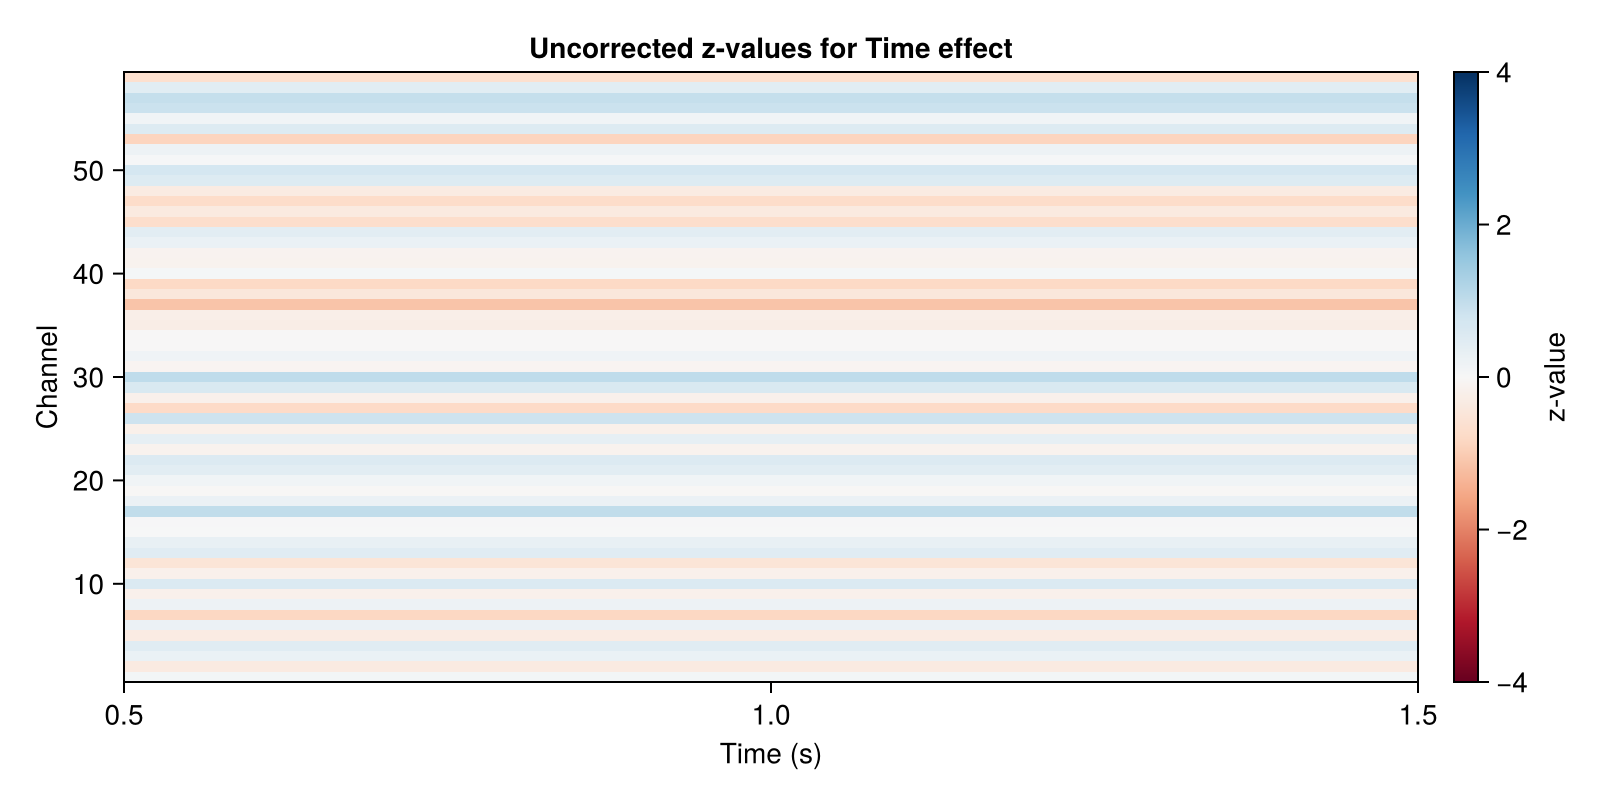

In [164]:
# Check uncorrected effects before running permutation test
# Extract coefficients for the stimtype effect
coefs = coeftable(m)

# Show available columns
println("Available columns: $(names(coefs))")
#println(r.coefname)

# Filter for stimtype coefficient
coef_stimtype = filter(r -> r.coefname == "Behavior & Group: A", coefs)
println("Rows for stimtype: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(coef_stimtype.time))
println("Unique channels: $(length(unique_channels))")
println("Unique times: $(length(unique_times))")

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate]
stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
z_vec = estimate_vec ./ stderror_vec

coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
z_summary = combine(
    groupby(coef_stimtype, [:channel, :time]),
    :z => (x -> mean(filter(!isnan, x))) => :z
)
sort!(z_summary, [:channel, :time])

# Replace NaN with 0 for visualization
z_summary.z = replace(z_summary.z, NaN => 0.0)

# Reshape z-values to channels × times
n_ch_coef = length(unique_channels)
n_t_coef = length(unique_times)
z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 2.0)
n_sig_uncorrected = sum(abs.(z_vals) .> 2.0)  # why 2? shouldn't it be 1.96??
max_z = maximum(abs.(z_vals))
peak_idx = argmax(abs.(z_vals))
peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

println("\n=== Uncorrected Effects (before permutation) ===")
println("Max |z|: $(round(max_z, digits=2))")
println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of z-values
fig_z = Figure(size = (800, 400))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected z-values for Time effect",
    xlabel = "Time (s)",
    ylabel = "Channel")
hm = heatmap!(ax_z, collect(unique_times), 1:n_ch_coef, z_vals', colormap = :RdBu, colorrange = (-4, 4))
Colorbar(fig_z[1, 2], hm, label = "z-value")
fig_z

In [165]:
extrema(z_vals)  # check these values with C3 calculation

(-1.144515657035443, 1.0309754612023816)

Significant cluster IDs: Int64[]


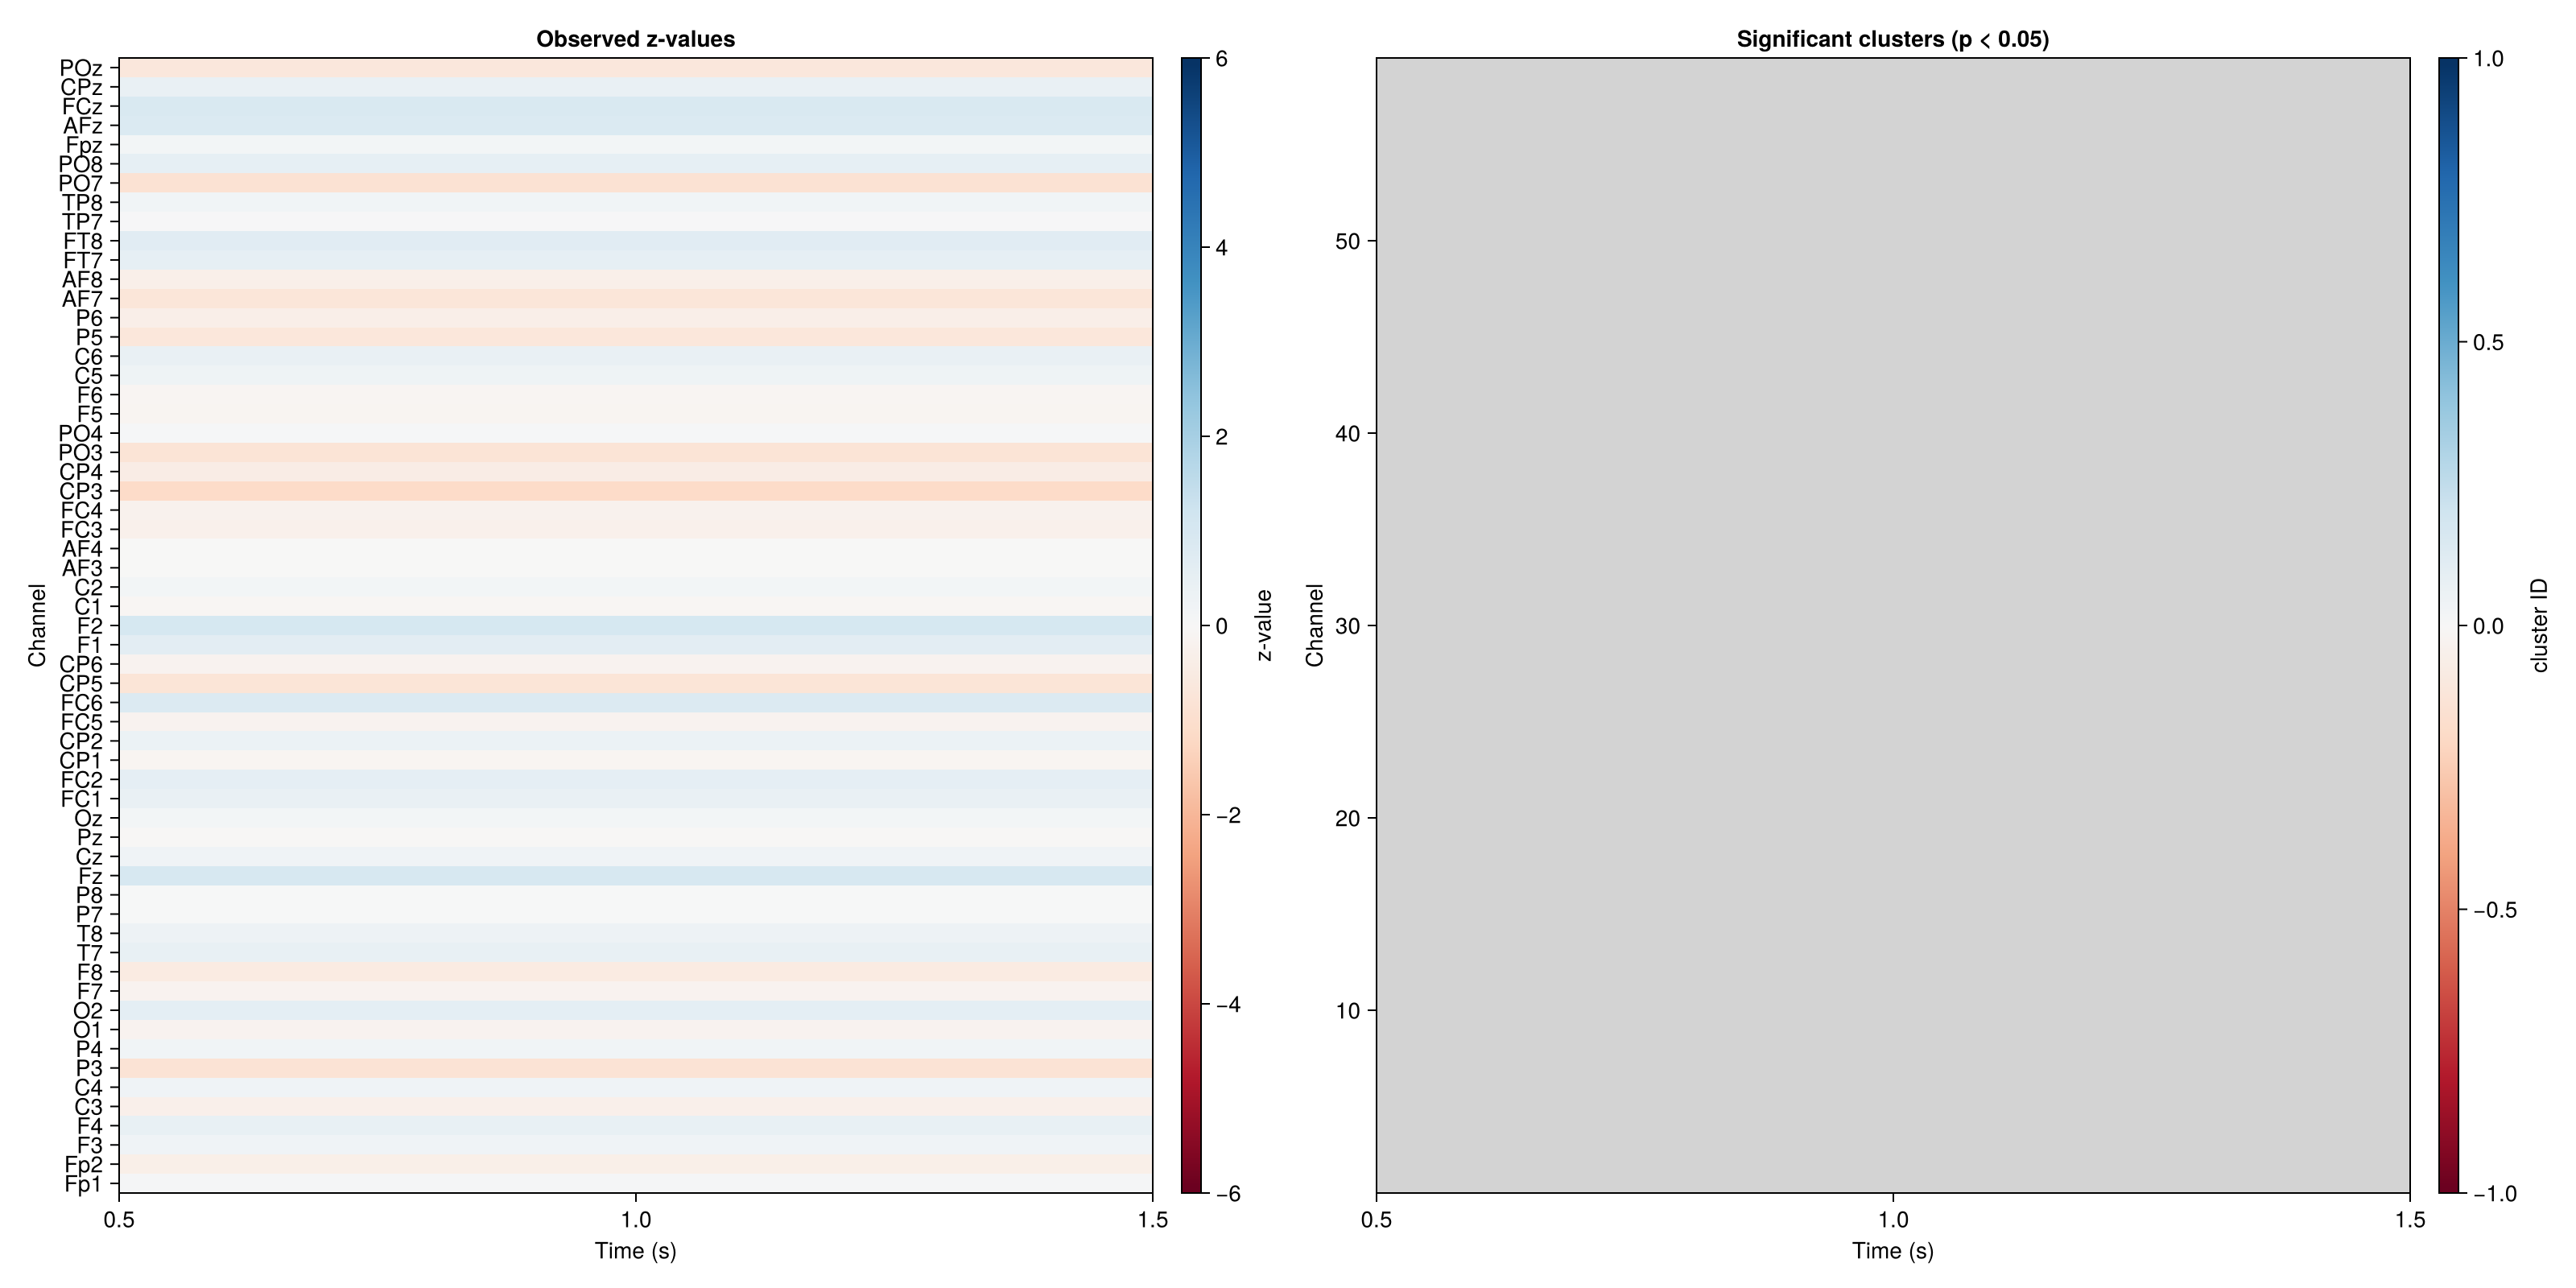

In [166]:
# 3. Run cluster-mass permutation test
n_channels = 59

observed = z_vals
pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, electrode_labels))
hm1 = heatmap!(ax1, collect(times), 1:n_channels, z_vals', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel")
hm2 = heatmap!(ax2, collect(times), 1:n_channels, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

In [167]:
n = size(adjacency, 1)
coords = Dict(row.ch_name => (row.x, row.y) for row in eachrow(positions_df))

xs = [get(coords, electrode_labels[i], (0.0, 0.0))[1] for i in 1:n]
ys = [get(coords, electrode_labels[i], (0.0, 0.0))[2] for i in 1:n]

pos2d = [Point2f(xs[i], ys[i]) for i in 1:n]

59-element Vector{Point{2, Float32}}:
 [0.31910187, 0.9022613]
 [0.60451525, 0.9022613]
 [0.26805818, 0.70231706]
 [0.6555589, 0.70231706]
 [0.23090428, 0.4630553]
 [0.69271284, 0.4630553]
 [0.26805818, 0.22379355]
 [0.6555589, 0.22379355]
 [0.31910187, 0.023849286]
 [0.60451525, 0.023849286]
 ⋮
 [0.022602523, 0.32034862]
 [0.90101457, 0.32034862]
 [0.19036429, 0.08944435]
 [0.7332528, 0.08944435]
 [0.46180853, 0.9248639]
 [0.46180853, 0.7760589]
 [0.46180853, 0.57594186]
 [0.46180853, 0.35016876]
 [0.46180853, 0.11926448]

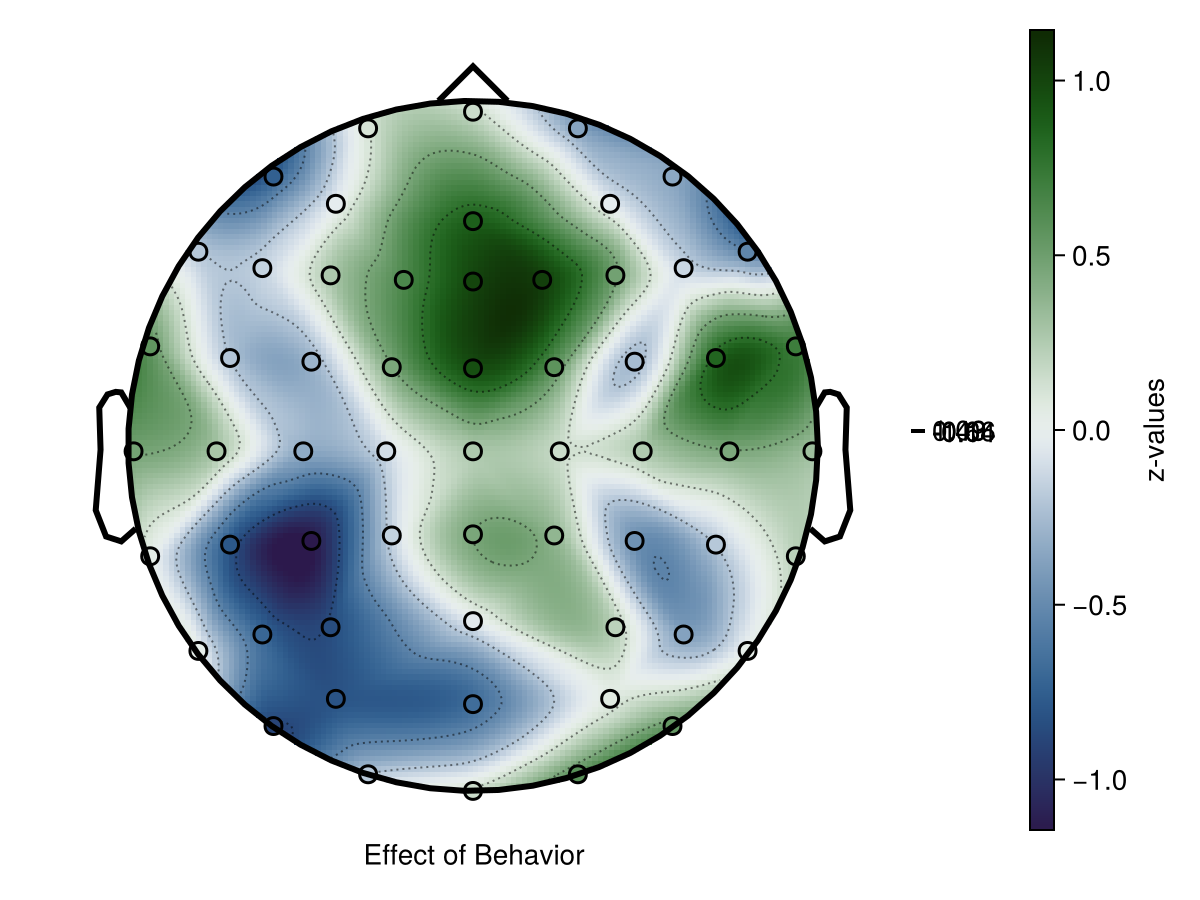

In [168]:
# create topoplot and butterfly plot for selected channels only

#pos3d = hart.electrodes["pos"][channel_idx, :]  # 32x3 matrix for selected channels
#pos2d = [Point2f(pos3d[i,1], pos3d[i,2]) for i in 1:size(pos3d,1)]  # convert to 2D points for topoplot
sig_mask = pvals_clustermass .< 0.05

cluster_data = copy(z_vals)
plot_data = reshape(cluster_data, size(cluster_data)..., 1)  # reshape for plotting (or use df)

min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))  # get the limits

#cluster_data[.!sig_mask] .= 0.0  # Set non-significant to zero (or NaN)
# Ensure correct orientation: time x channels
df = DataFrame(
    :estimate => vec(cluster_data),  # no transpose, time is slow axis, channels is fast axis
    :channel => repeat(1:size(cluster_data, 1), outer = size(cluster_data, 2)),
    :time => repeat(1:size(cluster_data, 2), inner = size(cluster_data, 1))
)

# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]

marker_colors = [is_sig ? :orange : :black for is_sig in sig_ch] # Set marker color: orange for significant, black for others
strokes = [is_sig ? 3 : 1.5 for is_sig in sig_ch]
sizes = fill(12, 59)

fig = Figure()

plot_topoplot!(
    fig[1, 1],
    plot_data[:, 1, 1];  # df
    positions = pos2d,
    #mapping=(; y=:estimate),
    axis = (; xlabel = "Effect of Behavior"),
    visual = (; colormap = :cork, contours = true, colorrange = (-limit, limit)),  # this is a hack
    #colorbar = (; limits = (-2.3, 2.3)),
    #colorbar = (; colorrange = (-2.3, 2.3)),
    #colorbar = (; height = 150, label = "z-values"), #, limits = (-4.5, 4.5)),
    colorbar = (;  label = "", width=1, height=1), # height
    topo_attributes = (;
        label_scatter = (;
            markersize = sizes,
            strokecolor = marker_colors,
            strokewidth = strokes)),
    )

Colorbar(fig[1, 2], colorrange = (-limit, limit), colormap = :cork, label = "z-values", height = 400)  # hack because colorbar does not match what I specify
#fig.colorrange = (-2.3, 2.3)
fig


In [169]:
min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))
colorrange = (-limit, limit)

(-1.144515657035443, 1.144515657035443)

Averaging across 1 time points
Any NaN in avg_topo: false


┌ Warning: No significant time points found; falling back to averaging across all times
└ @ Main /Users/mg/Desktop/ClusterComputation/notebooks/tutorial_notebook_Magda.ipynb:16


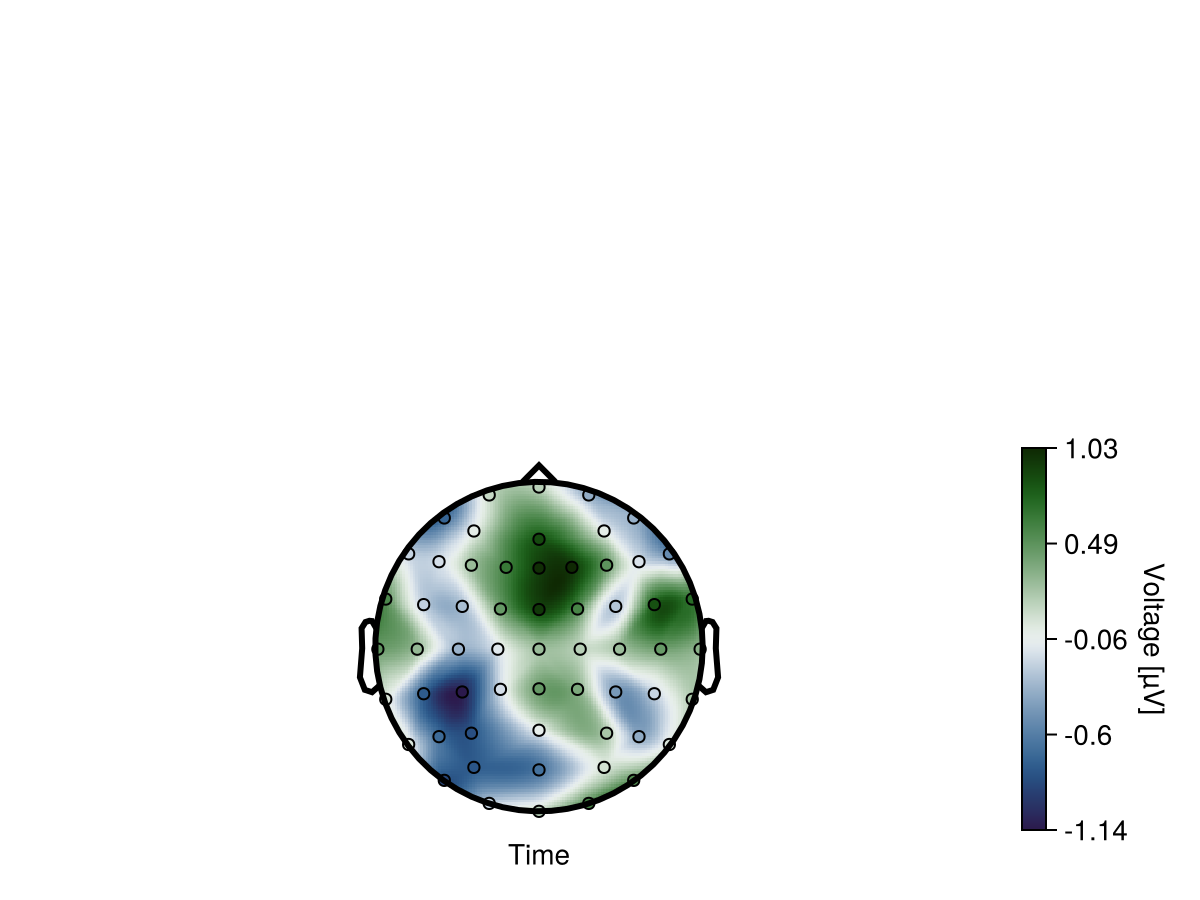

In [170]:
f = Figure()
# Average ERP across all trials for each channel and time
erp = mean(cluster_data; dims=3)[:,:,1]  # (channels x times)
df_erp = DataFrame(
    :amplitude => vec(erp),
    :channel => repeat(1:size(erp, 1), outer = size(erp, 2)),
    :time => repeat(1:size(erp, 2), inner = size(erp, 1))
)
#plot_butterfly!(f[1, 1:2], df_erp; positions = pos2d, mapping=(; y=:amplitude))
# Find significant time points (p < 0.05)
# sig_mask is channels x times, so get time indices where any channel is significant
sig_time_bool = vec(any(sig_mask, dims=1))
unique_times = sort(unique(df_erp.time))
sig_times = unique_times[sig_time_bool]
if isempty(sig_times)
    @warn "No significant time points found; falling back to averaging across all times"
    sig_times = unique_times
end
println("Averaging across $(length(sig_times)) time points")
# Compute average topography robustly (avoid averaging over empty selection)
avg_topo = Float64[]
for ch in 1:n_channels
    sel = (df_erp.channel .== ch) .& in.(df_erp.time, Ref(sig_times))
    vals = df_erp.amplitude[sel]
    if isempty(vals)
        push!(avg_topo, NaN)
    else
        push!(avg_topo, mean(vals))
    end
end
println("Any NaN in avg_topo: ", any(isnan, avg_topo))
if any(isnan, avg_topo)
    @warn "avg_topo contains NaNs for channels: $(findall(isnan, avg_topo))"
end
# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]
# Set marker color: red for significant, gray for others
marker_colors = [is_sig ? :orange : :black for is_sig in sig_ch]

strokes = [is_sig ? 2 : 1 for is_sig in sig_ch]

#colors = fill(:orange, 59)
sizes = fill(8, 59)

df = DataFrame(:amplitude => avg_topo, :channel => 1:n_channels)

plot_topoplot!(
    f[2, 1],
    df;
    positions = pos2d,
    mapping=(; y=:amplitude),
    visual = (; colormap = :cork, contours = false),
    #colorbar = (; limits = (-2.3, 2.3)),
    #colorbar = (; colorrange = (-2.3, 2.3)),
    topo_attributes = (;
        label_scatter = (;
            markersize = sizes,
            strokecolor = marker_colors,
            strokewidth = strokes)),
    )

f